In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv('Mall_Customers.csv')
print(df.head())

X = df.drop(columns=['CustomerID'])
X = pd.get_dummies(X, drop_first=True)
print("\nColumns used for clustering:")
print(X.columns)
kmeans_no_scale = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_no_scale = kmeans_no_scale.fit_predict(X)
sil_no_scale = silhouette_score(X, y_no_scale)
print("\n--- WITHOUT SCALING ---")
print("Cluster counts:\n", pd.Series(y_no_scale).value_counts())
print("Silhouette Score:", sil_no_scale)


age_col = X[['Age']]
other_cols = X.drop(columns=['Age'])
scaler = StandardScaler()
scaled_other = scaler.fit_transform(other_cols)
X_scaled_partial = np.concatenate([age_col.values, scaled_other], axis=1)
kmeans_scaled = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_scaled = kmeans_scaled.fit_predict(X_scaled_partial)
sil_scaled = silhouette_score(X_scaled_partial, y_scaled)
print("\n--- WITH SCALING (except Age) ---")
print("Cluster counts:\n", pd.Series(y_scaled).value_counts())
print("Silhouette Score:", sil_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=y_no_scale, cmap='viridis')
plt.title('Without Scaling')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.subplot(1, 2, 2)
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=y_scaled, cmap='viridis')
plt.title('With Scaling (except Age)')
plt.xlabel('Income')
plt.ylabel('Spending Score')

plt.tight_layout()
plt.show()

Dataset:
    vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost vehicle_type
0                  5   150000               15              5000          SUV
1                  3   120000               18              4000        Sedan
2                  8   250000               10              7000        Truck
3                  2    80000               22              2000    Hatchback
4                  4   100000               20              3000        Sedan
5                  7   220000               12              6500        Truck
6                  6   180000               16              5500          SUV
7                 10   300000                8              8000        Truck
8                  1    75000               24              1500    Hatchback
9                  9   280000                9              7500          SUV

Processed Features:
    mileage  fuel_efficiency  maintenance_cost  vehicle_type_Hatchback  \
0   150000               15          

c:\Users\k240810\.conda\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\k240810\.conda\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



--- WITHOUT SCALING ---
Cluster Labels: [2 2 1 0 0 1 2 1 0 1]
Cluster Counts:
 1    4
2    3
0    3
Name: count, dtype: int64
Silhouette Score: 0.5150954785160492

--- WITH SCALING ---
Cluster Labels: [2 2 1 0 0 1 2 1 0 1]
Cluster Counts:
 1    4
2    3
0    3
Name: count, dtype: int64
Silhouette Score: 0.4101283226399083


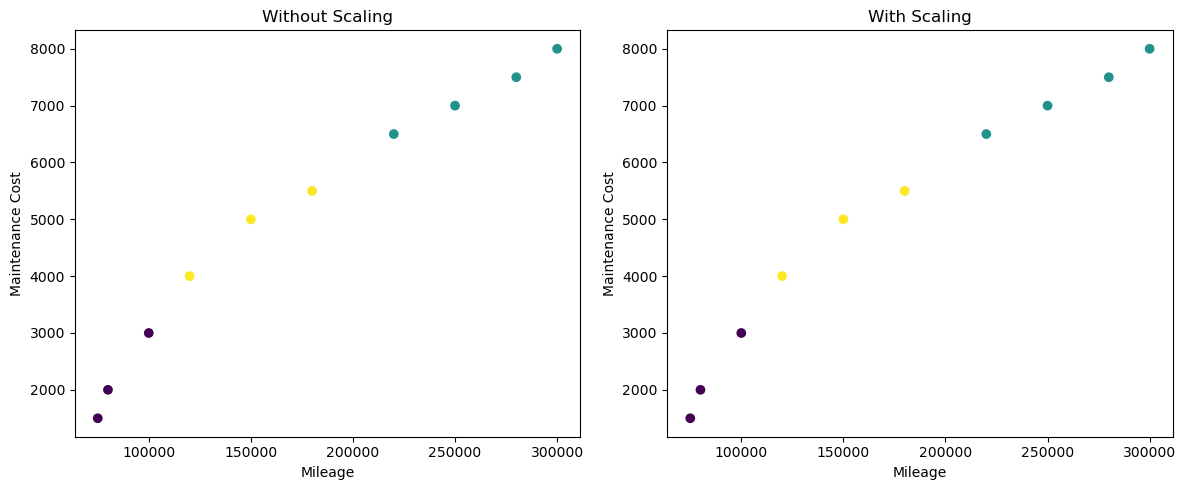

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}
df = pd.DataFrame(data)
print("Dataset:\n", df)
X = df.drop(columns=['vehicle_serial_no'])
X = pd.get_dummies(X, columns=['vehicle_type'])
print("\nProcessed Features:\n", X.head())

kmeans_no_scale = KMeans(n_clusters=3, random_state=42)
y_no_scale = kmeans_no_scale.fit_predict(X)
sil_no_scale = silhouette_score(X, y_no_scale)
print("\n--- WITHOUT SCALING ---")
print("Cluster Labels:", y_no_scale)
print("Cluster Counts:\n", pd.Series(y_no_scale).value_counts())
print("Silhouette Score:", sil_no_scale)

cat_cols = [col for col in X.columns if 'vehicle_type' in col]
num_cols = [col for col in X.columns if col not in cat_cols]
scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(X[num_cols])
X_scaled = np.concatenate([X_scaled_num, X[cat_cols].values], axis=1)
kmeans_scaled = KMeans(n_clusters=3, random_state=42)
y_scaled = kmeans_scaled.fit_predict(X_scaled)
sil_scaled = silhouette_score(X_scaled, y_scaled)
print("\n--- WITH SCALING ---")
print("Cluster Labels:", y_scaled)
print("Cluster Counts:\n", pd.Series(y_scaled).value_counts())
print("Silhouette Score:", sil_scaled)


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df['mileage'], df['maintenance_cost'], c=y_no_scale, cmap='viridis')
plt.title('Without Scaling')
plt.xlabel('Mileage')
plt.ylabel('Maintenance Cost')
plt.subplot(1, 2, 2)
plt.scatter(df['mileage'], df['maintenance_cost'], c=y_scaled, cmap='viridis')
plt.title('With Scaling')
plt.xlabel('Mileage')
plt.ylabel('Maintenance Cost')
plt.tight_layout()
plt.show()

Original Dataset:
    student_id  GPA  study_hours  attendance_rate
0         101  3.5           15               90
1         102  2.8            8               75
2         103  3.9           20               95
3         104  2.5            5               60
4         105  3.2           12               85
5         106  3.7           18               92
6         107  2.2            4               55
7         108  3.0           10               80
8         109  3.8           19               93
9         110  2.7            7               70


c:\Users\k240810\.conda\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\k240810\.conda\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\k240810\.conda\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\k240810\.conda\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans 

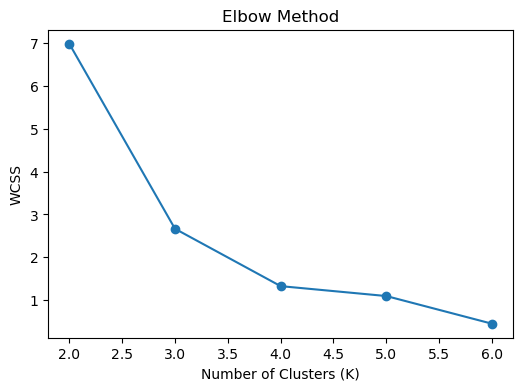


Final Dataset with Clusters:

   student_id  Cluster
0         101        1
1         102        2
2         103        1
3         104        0
4         105        2
5         106        1
6         107        0
7         108        2
8         109        1
9         110        2


c:\Users\k240810\.conda\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


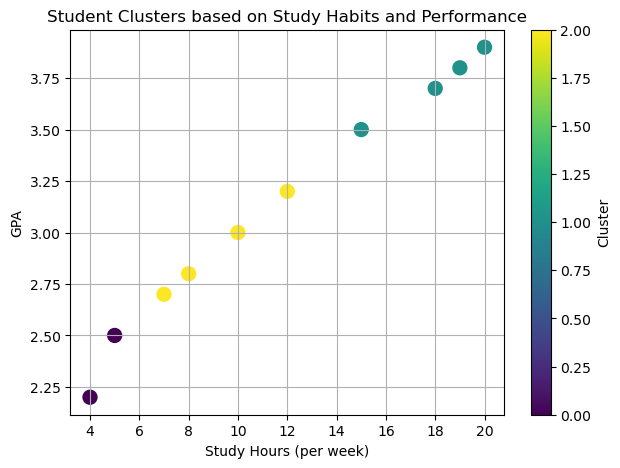

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'student_id': [101,102,103,104,105,106,107,108,109,110],
    'GPA': [3.5, 2.8, 3.9, 2.5, 3.2, 3.7, 2.2, 3.0, 3.8, 2.7],
    'study_hours': [15, 8, 20, 5, 12, 18, 4, 10, 19, 7],
    'attendance_rate': [90, 75, 95, 60, 85, 92, 55, 80, 93, 70]
}
df = pd.DataFrame(data)
print("Original Dataset:\n", df)

X = df[['GPA', 'study_hours', 'attendance_rate']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,7), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print("\nFinal Dataset with Clusters:\n")
print(df[['student_id', 'Cluster']])

plt.figure(figsize=(7,5))
scatter = plt.scatter(df['study_hours'], df['GPA'],
                      c=df['Cluster'], cmap='viridis', s=100)

plt.title('Student Clusters based on Study Habits and Performance')
plt.xlabel('Study Hours (per week)')
plt.ylabel('GPA')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()